In [98]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [99]:
data=pd.read_csv('/content/student_dataset_10000_rows.csv')
data.head(10)

,study_hours,attendance,sleep_hours,internet_usage,assignments_completed,previous_score,exam_score,placement_status
0,7,56,8,7,10,62,100.00,Placed
1,4,69,5,3,8,56,100.00,Placed
2,11,60,7,6,10,45,100.00,Placed
3,8,99,9,8,4,55,90.17,Placed
4,5,52,8,6,8,40,78.82,Placed
5,7,40,9,10,0,60,72.33,Placed
6,10,40,4,11,9,50,98.12,Placed
7,3,86,7,3,7,85,100.00,Placed
8,7,72,8,5,18,48,96.81,Placed
9,11,77,4,9,15,69,100.00,Placed


In [100]:
data.info()
data.shape
#no null values,(10000,8)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   study_hours            10000 non-null  int64  
 1   attendance             10000 non-null  int64  
 2   sleep_hours            10000 non-null  int64  
 3   internet_usage         10000 non-null  int64  
 4   assignments_completed  10000 non-null  int64  
 5   previous_score         10000 non-null  int64  
 6   exam_score             10000 non-null  float64
 7   placement_status       10000 non-null  object 
dtypes: float64(1), int64(6), object(1)
memory usage: 625.1+ KB


(10000, 8)

# What do I think?

So i believe that attendance and study hours can be linked, so can be true for examscore,previous score and placement status

So First... Lets check

In [101]:
data.columns

Index(['study_hours', 'attendance', 'sleep_hours', 'internet_usage',
       'assignments_completed', 'previous_score', 'exam_score',
       'placement_status'],
      dtype='object')

<Axes: xlabel='sleep_hours', ylabel='Count'>

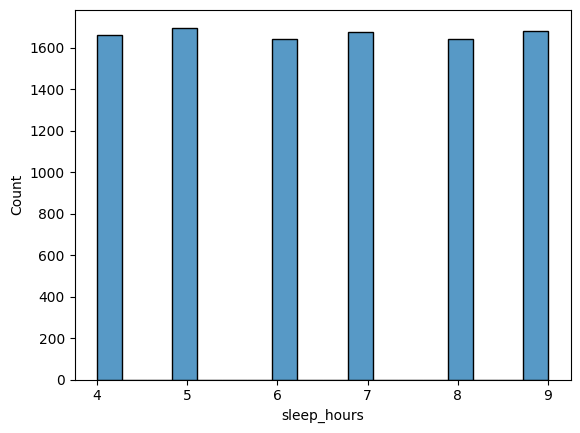

In [102]:
sns.histplot(data['sleep_hours'])
#nearly uniform

<Axes: xlabel='internet_usage', ylabel='Count'>

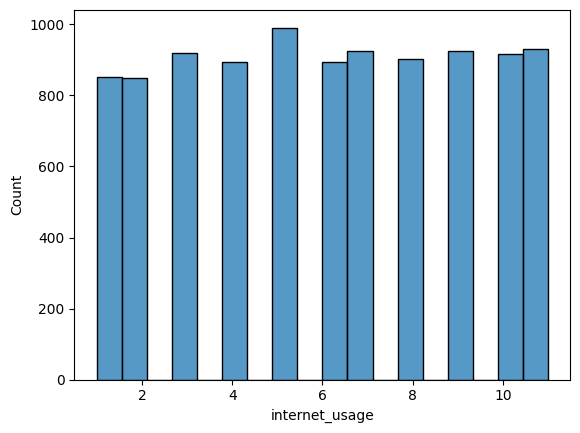

In [103]:
sns.histplot(data['internet_usage'])
#also nearly uniform

In [104]:
data["placement_status"].unique()
lp=len(data["placement_status"][data.placement_status=="Placed"])
ln=len(data["placement_status"][data.placement_status=="Not Placed"])
print(lp,ln)

8356 1644


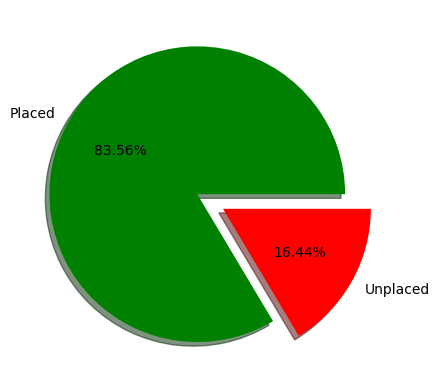

In [120]:
plt.pie([lp,ln],labels=["Placed","Unplaced"],
         autopct='%1.2f%%',explode=[0.0,0.2],shadow=True,colors=["g","r"])
plt.show()

In [106]:
data["placement_status"] = [1 if col == 'Placed' else 0 for col in data["placement_status"]]
data
#feature engineering

,study_hours,attendance,sleep_hours,internet_usage,assignments_completed,previous_score,exam_score,placement_status
0,7,56,8,7,10,62,100.00,1
1,4,69,5,3,8,56,100.00,1
2,11,60,7,6,10,45,100.00,1
3,8,99,9,8,4,55,90.17,1
4,5,52,8,6,8,40,78.82,1
...,...,...,...,...,...,...,...,...
9995,2,58,9,7,8,88,69.31,0
9996,7,98,6,9,4,87,100.00,1
9997,10,44,8,5,10,37,95.94,1
9998,10,75,7,5,8,52,88.61,1


Now I believe that the placement students have some more positive features compared to non-placement students so lemme check those relaations

<Axes: xlabel='placement_status', ylabel='exam_score'>

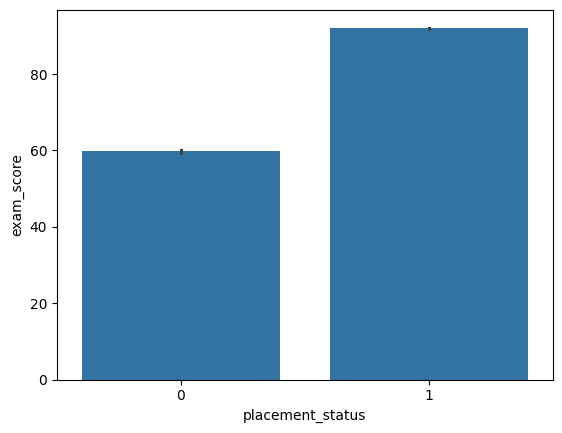

In [107]:
#relation between previous exam score and placement
sns.barplot(y=data["exam_score"],x=data["placement_status"])
#obviously who scored more had more placement

<Axes: xlabel='placement_status', ylabel='attendance'>

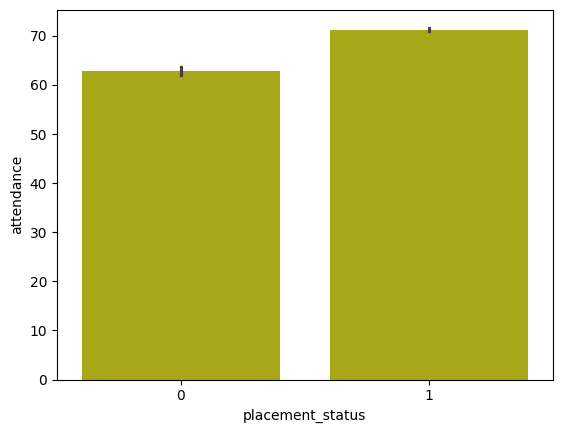

In [108]:
sns.barplot(y=data["attendance"],x=data["placement_status"],color="y")
#more placement had a slight bias to more present students

Text(0.5, 1.0, 'Study to Placement Ratio')

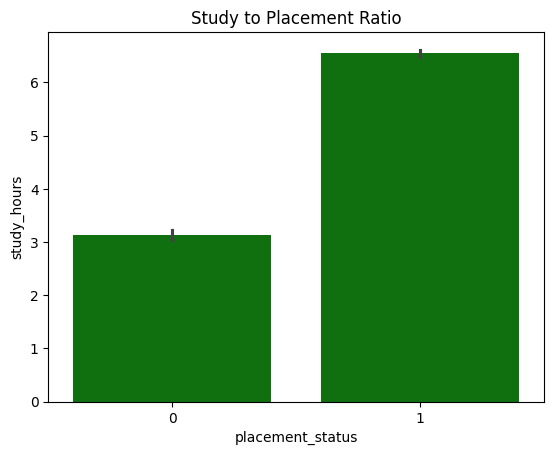

In [109]:
sns.barplot(y=data["study_hours"],x=data["placement_status"],color="g")
plt.title("Study to Placement Ratio")
#heavy relation of study hours for placements
#the more you studied the easily you could crack

<Axes: xlabel='placement_status', ylabel='internet_usage'>

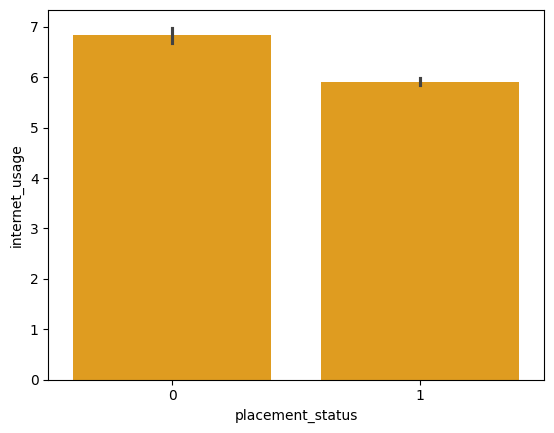

In [110]:
sns.barplot(y=data["internet_usage"],x=data["placement_status"],color='orange')
#failure where more on their phones

<Axes: xlabel='placement_status', ylabel='previous_score'>

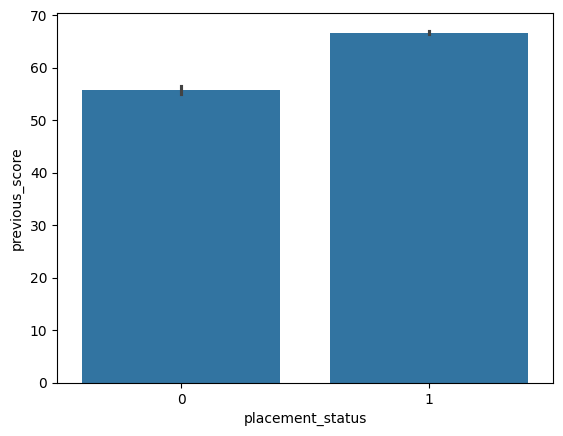

In [111]:
sns.barplot(y=data["previous_score"],x=data["placement_status"])
#slight relation and again more score means more placement its just that the
#score here is within 70 and exam score was between 100

<Axes: xlabel='placement_status', ylabel='sleep_hours'>

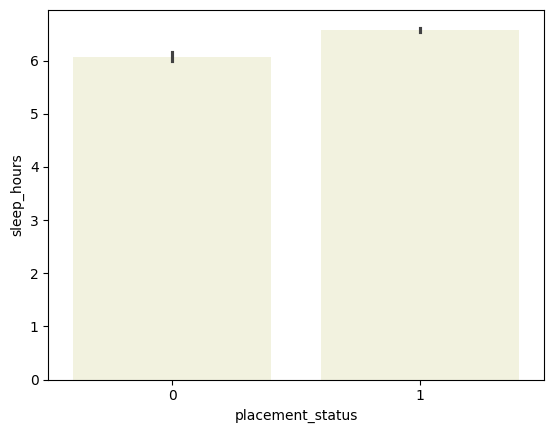

In [112]:
sns.barplot(y=data["sleep_hours"],x=data["placement_status"],color="beige")
#intresting,better placement holders also sleep more

In [113]:
data["Remaining_hours"]=24-data["sleep_hours"]-data["study_hours"]

<Axes: xlabel='placement_status', ylabel='Remaining_hours'>

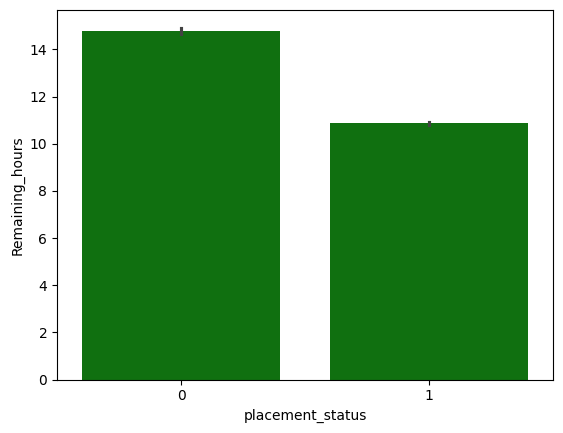

In [114]:
sns.barplot(y=data["Remaining_hours"],x=data["placement_status"],color="g")
#Placement holders didnt have a lot of time in the day

'\nhighest relation in features between:\nexam_score and all other features\nstudy_hours and remain_hours\n'

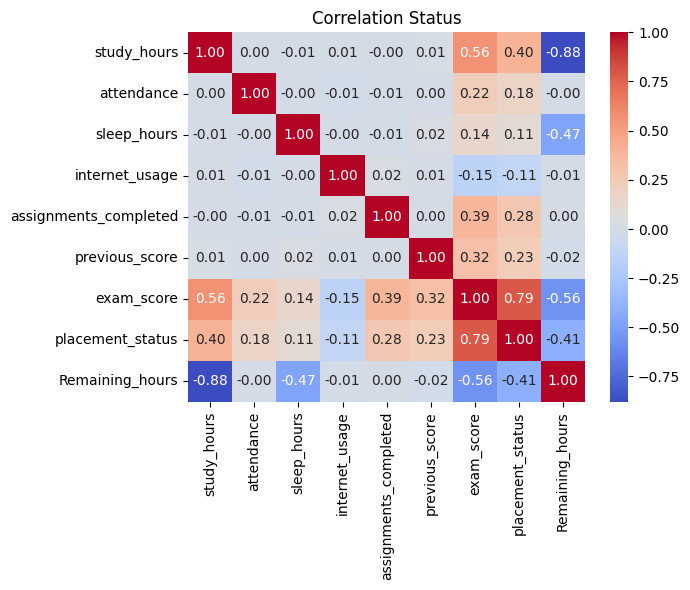

In [115]:
corr=data.corr()
sns.heatmap(corr,cmap="coolwarm",annot=True,fmt='0.2f')
plt.title("Correlation Status")
'''
highest relation in features between:
exam_score and all other features
study_hours and remain_hours
'''
#But we see, every feature affects the placement status

#Model Training

In [116]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(data.drop("placement_status",axis=1),
                                               data["placement_status"],test_size=0.2,random_state=0)

In [117]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score

lr=LogisticRegression()
lr.fit(x_train,y_train)
p=lr.predict(x_test)
print("Predicted value:",p[898],"Actual value:",y_test[898])
print(lr.score(x_test,y_test),"\n","Accuracy:",accuracy_score(y_test,p),"\n",'Precision:',precision_score(y_test,p))

#very high score

Predicted value: 1 Actual value: 1
0.999 
 Accuracy: 0.999 
 Precision: 1.0


In [124]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
param_grid={'C':[0.1,1,10,100],
            'gamma':[1,0.1,0.01,0.001],
            'kernel':['rbf']}
g=GridSearchCV(SVC(),param_grid,refit=True,verbose=1)
g.fit(x_train,y_train) #basically we are tweeking to find the values of [C & gamma]
print(g.best_estimator_)


Fitting 5 folds for each of 16 candidates, totalling 80 fits
SVC(C=100, gamma=0.001)


'\nprint("Predicted value:",sp[898],"Actual value:",y_test[898])\nprint(lr.score(x_test,y_test),"\n","Accuracy:",accuracy_score(y_test,p),"\n",\'Precision:\',precision_score(y_test,p))'

In [139]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
xt=sc.fit_transform(x_train)
xte=sc.fit_transform(x_test)

In [143]:
svm=SVC(C=100, gamma=0.001)
svm.fit(xt,y_train)
sp=svm.predict(xte)
print("Predicted value:",sp[898],"Actual value:",y_test[898])
print(svm.score(xte,y_test),"\n","Accuracy:",accuracy_score(y_test,sp),"\n",'Precision:',precision_score(y_test,sp))


Predicted value: 1 Actual value: 1
0.997 
 Accuracy: 0.997 
 Precision: 0.9988059701492538


We saw that LogisticRegression gave us a better score for the dataset with very high accuracy and precision

SO WE CHOOSE LOGISTIC REGRESSION SET

In [145]:
data.columns

Index(['study_hours', 'attendance', 'sleep_hours', 'internet_usage',
       'assignments_completed', 'previous_score', 'exam_score',
       'placement_status', 'Remaining_hours'],
      dtype='object')

#Testing

In [155]:
import warnings
warnings.filterwarnings('ignore')

n=input("How many Test Cases do you want to run?")
def pep(n):
  for i in range(int(n)):

    sh=int(input("Study Hours:"))
    at=int(input("Attendance:"))
    sl=int(input("Sleep Hours:"))
    inr=int(input("Internet Usage:"))
    ac=int(input("Assignments Completed:"))
    ps=int(input("Previous Score:"))
    ex=int(input("Exam Score:"))
    pp=int(input("Placement Status:"))

    remain_hours=24-sh-sl
    nd=np.array([[sh,at,sl,inr,ac,ps,ex,remain_hours]])
    p=lr.predict(nd)
    print("\n")
    print("Prediction:",int(p))
    print("Actual Value:",pp)
pep(n)

How many Test Cases do you want to run?1
Study Hours:3
Attendance:55
Sleep Hours:6
Internet Usage:7
Assignments Completed:4
Previous Score:52
Exam Score:58
Placement Status:0
Prediction: 0
Actual Value: 0
